# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.core import massbalance
from oggm import tasks
from oggm.core.massbalance import MultipleFlowlineMassBalance

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact, fixed

# Install SAFE package and import required functions
%pip install SAFEpython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
import safepython.plot_functions as pf


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now prepare to load the glacier dierectories from the OGGM.

In [2]:
cfg.initialize(logging_level='WARNING')
# cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PATHS['working_dir'] = "/mnt/c/Users/yg25019/Documents/sensitivity_output"
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['use_multiprocessing'] = True  # To speed up sensitivity analysis runs
cfg.PARAMS['mp_processes'] = os.cpu_count()  # Use all available cores
cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2026-02-18 16:37:03: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-18 16:37:03: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-18 16:37:03: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-02-18 16:37:03: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-02-18 16:37:03: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-02-18 16:37:03: oggm.cfg: Multiprocessing switched ON after user settings.
2026-02-18 16:37:03: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [3]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-02-18 16:37:04: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-18 16:37:04: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


Creating the dataframe and adding the observed mass balance.

In [4]:
# Get the observed mass balance and set up dataframe

mbdf = gdir_hef.get_ref_mb_data().loc[1979:2019] # WGMS data for HEF
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[1979:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison


# Step 1 - The OGGM Runner, to produce runoff simulations

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

This runner will produce a timeseries for the runoff.

The method will use run_with_hydro to create the hydrological data required to calculate the runoff in the OGGM.

In [5]:
# Hydrological model workflow steps before running with hydro
cfg.PARAMS['evolution_model'] = 'FluxBased'
cfg.PARAMS['store_model_geometry'] = True

2026-02-18 16:37:10: oggm.cfg: PARAMS['evolution_model'] changed from `SemiImplicit` to `FluxBased`.


In [6]:
def write_runoff_to_csv_file(csv_filepath, years,  runoff, row_index):
    # Write the runoff output to a csv file, with the index being the same as the input sample row index, so we can link the runoff output to the input parameters
    import pandas as pd
    df = pd.DataFrame({
            'years': years,
            'runoff': runoff
                })
    df.to_csv(cfg.PATHS['working_dir'] + '/' + str(row_index) + '_' + csv_filepath, index=False)

In [98]:
def run_with_runoff(sample_row,
                    row_index, 
                    gdir, 
                    years=range(1979, 2020), # Observational data period for HEF, but can be changed to a different period if desired
                    init_model_yr=1901, # Was 1979
                    ys=1901, # Was 1979
                    min_ys=1901, # Was 1979
                    ref_area_yr=2004,
                    spinup_period=21,
                    settings_filesuffix='',
                    csv_filepath='runoff_output.csv'):
    
    # TODO: Add docstring to this function, and also check how the settings_filesuffix is being used in the rest of the code and whether we need it here, add explanations for each parameter
    
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for the glacier
    gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this?
    
    # Set the parameter values
    melt_f, prcp_fac, temp_bias = sample_row

    # TODO: Shouldn't need to do this with the settings_file_suffix?
    # Can use the other style of massbalance model?
    mb = MultipleFlowlineMassBalance(
        gdir,
        mb_model_class=massbalance.MonthlyTIModel,
        melt_f=float(melt_f),
        prcp_fac=float(prcp_fac),
        temp_bias=float(temp_bias),
        check_calib_params=False,
        ) 
    
    fls = gdir.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mb.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance  

    # Create unique file identifier based on parameters, where the model output is saved
    file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'
    
    # Run with hydro
    workflow.execute_entity_task(
        tasks.run_with_hydro,
        [gdir],
        run_task=tasks.run_from_climate_data,
        ys=ys, # The simulation start year
        min_ys=min_ys, # For the run from climate data, to ensure we have data from 1979
        init_model_yr=init_model_yr,
        ref_area_yr=ref_area_yr,
        mb_model=mb, # The modified MB model
        store_monthly_hydro=True,
        output_filesuffix=file_id,
        settings_filesuffix='_historical' # TODO: Check how to use this with the rest of the code?
    )

    with xr.open_dataset(gdir.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()
        
    # These summed variabels give the total runoff from the glacier
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']
    df_annual = ds[runoff_vars].to_dataframe()

    # Years we are considering for the runoff output - this needs to be a decided period after the model has reached an equilibrium state - here we are taking the last 20 years of the model run, but this could be changed to be a different period
    year_1 = str(years[0]+spinup_period)+'.0'
    year_2 = str(years[-1])+'.0'

    # Runoff is in kg, we convert to Gt (or Mt) and take the sum of the different runoff components to get total runoff from the glacier
    df_annual = df_annual.loc[year_1:year_2]
    df_runoff = df_annual[runoff_vars].clip(0) * 1e-9

    # Convert them to megatonnes (instead of kg)
    runoff = df_runoff.sum(axis=1).to_numpy()

    write_runoff_to_csv_file(csv_filepath, list(range(years[0]+spinup_period, years[-1]+1)), runoff, row_index)

    return np.array(runoff)

In [68]:
# The equivalent function for mass balance (TODO: Check that this works correctly in comparison with the one in the other notebook and can be used if needed)
def run_with_mass_balance(sample_row, 
                    gdir, 
                    years=range(1979, 2020), # Observational data period for HEF, but can be changed to a different period if desired
                    init_model_yr=1901, # Was 1979
                    ys=1901, # Was 1979
                    min_ys=1901, # Was 1979
                    ref_area_yr=2004,
                    spinup_period=21,
                    settings_filesuffix=''):
    
    # TODO: Add docstring to this function, and also check how the settings_filesuffix is being used in the rest of the code and whether we need it here, add explanations for each parameter
    
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for the glacier
    gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this?
    
    # Set the parameter values
    melt_f, prcp_fac, temp_bias = sample_row

    # TODO: Shouldn't need to do this with the settings_file_suffix?
    # Can use the other style of massbalance model?
    mb = MultipleFlowlineMassBalance(
        gdir,
        mb_model_class=massbalance.MonthlyTIModel,
        melt_f=float(melt_f),
        prcp_fac=float(prcp_fac),
        temp_bias=float(temp_bias),
        check_calib_params=False,
        ) 
    
    fls = gdir.read_pickle('inversion_flowlines') # Read flowlines
    mbdf['mod_mb'] = mb.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance  

    return np.array(mbdf['mod_mb'])

The below method calculates the output metrics we will be using to understand the output of our hydrological simulations and our runoff timeseries. We currently do not have any observed data and so we are unsure of the values to expect, but we can still look into the mean and standard deviation, and use these in our sensitivity analysis.

Using the mean and standard deviation can give us a good picture of the data we have generated.

In [7]:
def hydro_output_metric_calculator(runoff):
    '''
    Calculates the output metrics for runoff, the mean and the standard deviation. 

    This is currently only used for calculting the mean and standard deviation of the runoff
    but can be added to in the future.

    Parameters:
    ------------

    runoff: np.array
        The runoff time series generated from the oggm_sim method, when the output is the runoff time series.

    Return:
    ------------

    YY: np.array
        An array containing the values of:
            - The annual runoff mean.
            - The annual runoff standard deviation.
    '''
    YY = np.nan * np.ones((len(runoff), 2))

    for i, x in enumerate(runoff):
        YY[i,0] = np.mean(x)
        YY[i,1] = np.std(x)

    return YY

In [8]:
def runoff_execution(fun_test, X, gdir, *args):
    runoff = []

    for i, sample_row in enumerate(X):

        out = workflow.execute_entity_task(
            fun_test,
            [gdir],                    # must be list
            mb_params=sample_row,
            row_index=i,
            years=args[0],
            init_model_yr=args[1],
            ys=args[2],
            min_ys=args[3],
            ref_area_yr=args[4],
            spinup_period=args[5],
            settings_filesuffix=args[6],
            csv_filepath=args[7],
            run_task=args[8],
            mb_model_method=args[9]
        )

        # execute_entity_task returns a LIST of results (one per gdir)
        runoff.append(out[0])

    YY = hydro_output_metric_calculator(runoff)
    return YY

In [109]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 2.0, -0.1]) # Minimum values for each parameter
x_max = np.array([3.0, 4.0, 0.1]) # Maximum values for each parameter
# The default ranges error with the dynamic spinup, we need to reduce these ranges - ideally to something closer to the Hinteresfirner glacier to be able to complete a dynamic spinup
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 5 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

YY = runoff_execution(run_with_runoff, 
                 X, 
                 gdir_hef, 
                 range(1979, 2020), 
                 1901, 
                 1901, 
                 1901, 
                 2004, 
                 21, 
                 '',
                 'runoff_output.csv') 

2026-02-18 15:33:48: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 15:33:49: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-18 15:33:51: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 15:33:51: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


20
20


2026-02-18 15:33:54: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 15:33:54: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


20
20


2026-02-18 15:33:56: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 15:33:56: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


20
20


2026-02-18 15:34:01: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 15:34:01: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


20
20
20
20


In [110]:
YY

array([[31.87895344,  4.52544687],
       [20.68683338,  2.97792363],
       [26.12395155,  3.8483961 ],
       [39.69755884,  5.73027553],
       [54.32627295,  4.68129084]])

## One-at-a-time Sensitivity Analysis

We will start off with some one-at-a-time sensitivity analysis. In the below we vary the runoff by altering one parameter at a time within the given ranges below, this can give us an idea of how the runoff is affected by changing each parameter.

In [92]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_hydro_function(gdir, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    runoff = run_with_runoff(param, gdir) # Using the runoff output here instead of the mass balance
    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(range(2000,2020), runoff, label='sim', color='k')
    plt.ylabel('Runoff (Mt)')
    plt.xlabel('Year')
    plt.legend()

# Create interactive plot, the toggles will change the parameter values 
interact(oat_hydro_function,
         gdir = fixed(workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]),
         melt_f = (1.5, 7.0, 0.1),  
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-0.5, 0.5, 0.1)); 

2026-02-18 15:16:41: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-18 15:16:41: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


interactive(children=(FloatSlider(value=5.0, description='melt_f', max=7.0, min=1.5), FloatSlider(value=3.4, d…

# GSA - Global Sensitivity Analysis

For our Global Sensitivity Analysis here we will be initially using Regional Sensitivity Analysis (RSA) and exploring PAWN in the SAFE Toolbox later on. More information on the RSA method can be seen in [Pianosi et al., 2016](https://www.sciencedirect.com/science/article/pii/S1364815216300287?fr=RR-2&ref=pdf_download&rr=9c07930109fe6535#bib67).

RSA is also called Monte Carlo filtering, here we split input samples depending on whether the associated output is above or below a prescribed threshold. Then the two input sets are compared to gain insight on the model behaviour and mapping.

RSA has been widely used in applications where the model output is an objective function (i.e. a measure of the model accuracy against observations) and splitting the criterion reflects the acheivement of a minimum requirement of model performance. This works well for our Mass-Balance sensitivity in the OGGM since we have access to WGMS data from observations of the Mass-Balance. We will be comparing the fit-to-data metrics of: the difference in mean values, the difference in standard deviation values and the RMSD. In an ideal scenario, we will be aiming to get this as close to 0 as possible and so we can use this as our RSA threshold. 

We will be using AAT Sampling from SAFE to perform global sampling. This method will be creating Monte Carlo Simulations, we will start by plotting the mass balance time series resulting from the Monte Carlo simulations and analyse the results.

However, the RSA typically requires a specified threshold. We currently do not have access to runoff data to provide a threshold and compare our simulated outputs. To work around this issue and apply RSA without specifying thresholds, we can group the ranked output samples into a prescribed number (e.g. 10) and compare the 10 resulting distribution functions of the input factors. This isn't currently implemented in SAFE, so we will be attempting an alternative method which does not require a threshold, PAWN. Which is a novel density-based method.

We will however include the original SAFE implementation of RSA for further exploration, and some arbitrary thresholds. If we do obtain the values of the observed mean runoff and standard deviation of runoff then we can easily change the code to implement the method correctly.


### Running Monte Carlo Simulations

Now taking AAT samples with the OGGM wrapper for both the mass balance and the runoff timeseries.

In [12]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 2.0, -0.1]) # Minimum values for each parameter
x_max = np.array([3.0, 4.0, 0.1]) # Maximum values for each parameter
# The default ranges error with the dynamic spinup, we need to reduce these ranges - ideally to something closer to the Hinteresfirner glacier to be able to complete a dynamic spinup
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 50 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

# cfg.PARAMS['use_multiprocessing']=False

runoff_sim = model_execution(run_with_runoff, X, gdir_hef) # Running 50 takes 7 mins? in Pret, 3.5 mins in office? - linearly

2026-02-18 11:31:30: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 11:31:30: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-18 11:31:35: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 11:31:35: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


Filepath /tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/model_diagnostics_hydro_mf1.65_pf3.25_tb0.06.nc


2026-02-18 11:31:41: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 11:31:41: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


Filepath /tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/model_diagnostics_hydro_mf1.65_pf3.25_tb0.06.nc


2026-02-18 11:31:47: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 11:31:47: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


...

2026-02-18 11:32:54: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 11:32:54: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


Filepath /tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/model_diagnostics_hydro_mf1.73_pf2.10_tb0.02.nc


2026-02-18 11:32:56: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-18 11:32:56: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.


Filepath /tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/model_diagnostics_hydro_mf1.88_pf2.55_tb-0.06.nc


KeyboardInterrupt: 

Now reshaping the output to extract the mass balance and the runoff timeseries for sensitivity analysis.

In [ ]:
# We are simulating over the years 2000-2020, but this can be changed to a different period if desired
sim_years = range(2000,2020)

## Runoff Sensitivity for the years 2000-2020

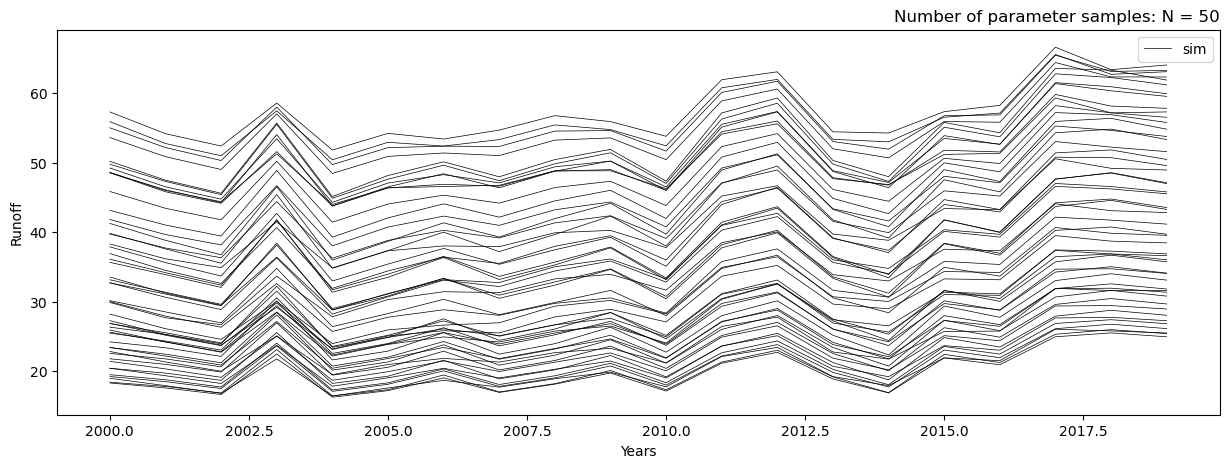

In [ ]:
# Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
plt.figure(figsize=[15,5])
for j in range(runoff_sim.shape[0]):
    plt.plot(sim_years, runoff_sim[j], linewidth = 0.5, color ='k')
plt.ylabel('Runoff'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

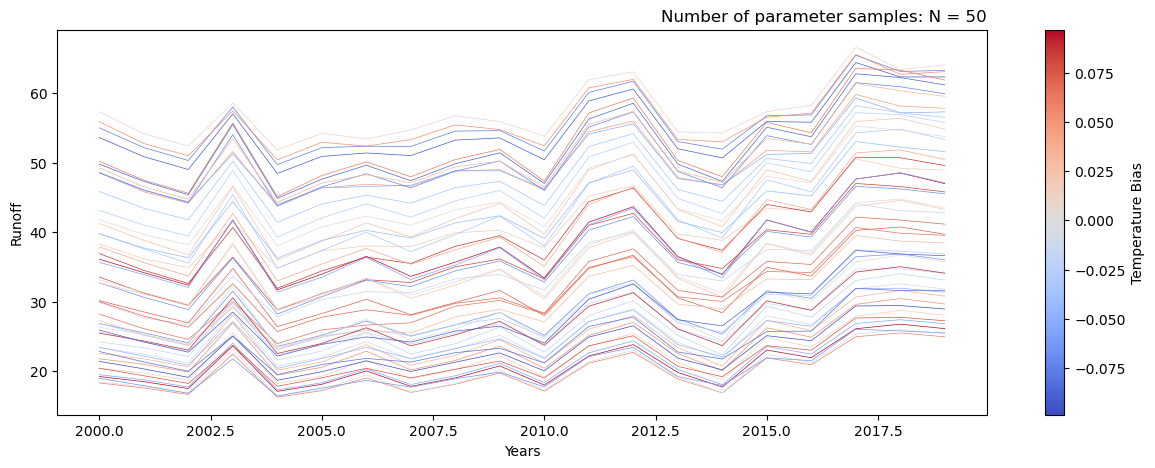

In [ ]:
# Also colour mapping (retrospectively) based on temp_bias values
import matplotlib.pyplot as plt
import numpy as np

temp_bias_index = 2  # Index of temp_bias in X

import matplotlib.pyplot as plt
import numpy as np

# Colormap and normalization
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=X[:, temp_bias_index].min(), vmax=X[:, temp_bias_index].max())

fig, ax = plt.subplots(figsize=(15, 5))

# Plot each simulation with color based on temp_bias
for i in range(len(runoff_sim)):  # assuming QQ_runoff is (N, time)
    color = cmap(norm(X[i, temp_bias_index]))
    ax.plot(sim_years, runoff_sim[i], linewidth=0.5, color=color)

ax.set_ylabel('Runoff')
ax.set_xlabel('Years')
ax.set_title(f"Number of parameter samples: N = {N}", loc='right')

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Temperature Bias')

plt.show()

In [ ]:
YY_hydro = hydro_output_metric_calculator(runoff_sim)

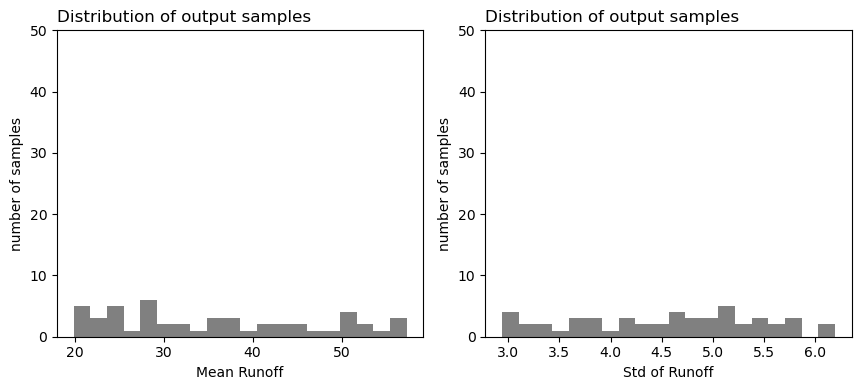

In [ ]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,0], bins=20, color='grey');
plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,1], bins=20, color='grey');
plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.tight_layout()

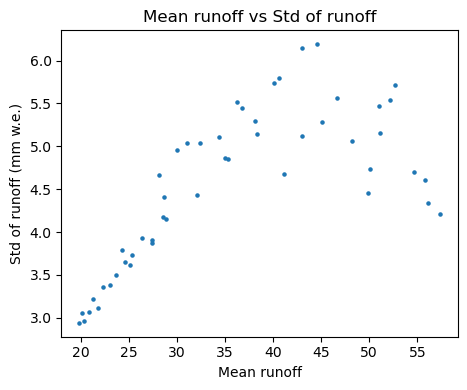

In [ ]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY_hydro[:,0], YY_hydro[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),

plt.tight_layout()
plt.show()


In [ ]:
Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY_hydro[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

In [ ]:
temp_bias_index = 2

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY_hydro[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

# Quantitative sensitivity: RSA with bootstrapping

Note: This is currently an abitrary threshold in which we can update if we obtain the desired values. I have put 25, this is the runoff standard deviation and mean value in Megatonnes per year. 

The RSA sensitivity analysis may be incorrect due to considering an arbitrary threshold, but this is an example of how the RSA can be used in this notebook with the OGGM runoff output.

If we obtain the correct values we can add this into our code easily.

/home/chloe/miniconda3/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:337: UserWarning: Statistics were computed using 30 bootstrap resamples instead of 50
  warn('Statistics were computed using ' + '%d' % (np.sum(idx))+


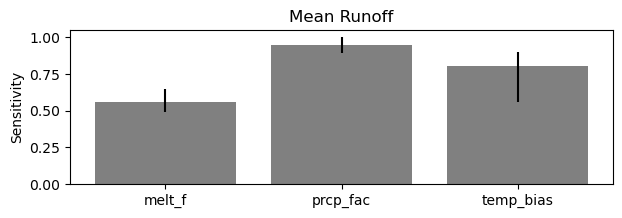

/home/chloe/miniconda3/envs/oggm_env/lib/python3.11/site-packages/safepython/RSA_thres.py:303: UserWarning: Cannot find any output value below the threshold! Try increasing the threshold value
  warn('Cannot find any output value below the threshold! Try increasing the threshold value')
/home/chloe/miniconda3/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:337: UserWarning: Statistics were computed using 42 bootstrap resamples instead of 50
  warn('Statistics were computed using ' + '%d' % (np.sum(idx))+


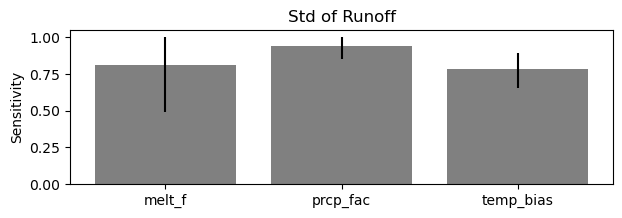

In [ ]:
Nboot = 50 # Number of resamples used for bootstrapping
# TODO: Currently, we do not have observed hydro data for the runoff to set targets against?
# For now, we can just set some arbitrary target values to see the sensitivity indices
#  When we know what we are doing this will need to be updated - i.e. glacier we are investigating, questions we want to answer etc.
for i in range(2):
    if i==0:
        Y=YY_hydro[:,0]
        target=20 # placeholder target
    if i==1:
        Y=YY_hydro[:,1]
        target=3 # placeholder target

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

## Investigating the relationship between parameters and the runoff

Here we will be plotting a combination of all the parameters we are investigating sensitivity for in a scatter plot, and colour-mapping the points by the values of the output metrics.

We have investigated sensitivity above, but this will allow us to investigate relationships of pairs of parameters in a bit more detail with the outputs of the runoff (both the mean of the runoff and the standard deviation of the runoff). 

In [ ]:
def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], X[:, i-1], 
                         c=YY_hydro[:, j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Mean Runoff (Mt)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

## PAWN Sensitivity Analysis

Above, for the Global Sensitivity Analysis we have used only RSA with bootstapping as our sensitivity analysis technique. 

As we have discussed, RSA requires a target value to differentiate between "behavioural" and "non-behavioural", which will reflect the sensitivities of our parameters. For runoff, as previously stated, we do not have an obvious metric to compare our data to. So we will investigate the use of another method in which we don't need this target value.

We will now move onto the PAWN technique to try another method of Sensitivity Analysis in the SAFE Toolbox that does not require a target value.

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

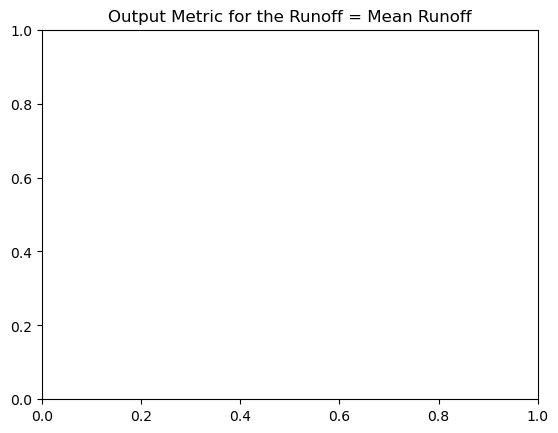

In [ ]:
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def runoff_pawn_function(metric='Mean Runoff', n = 5, aggr = 'median', Nboot = 500):
    # Extract output metric:
    if metric == 'Mean Runoff':
        i = 0
    elif metric == 'Std of Runoff':
        i = 1   
    Y = YY_hydro[:, i]; 

    X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(X, Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output Metric for the Runoff = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_labels, Y_Label='sensitivity (max KS)')
    plt.show()

interact(runoff_pawn_function, metric = ['Mean Runoff','Std of Runoff'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));


# Calling this from the version in the OGGM - trying it to check that it works

In [15]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
cfg.PARAMS['error_when_glacier_reaches_boundaries'] = False
gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 2.0, -0.1]) # Minimum values for each parameter
x_max = np.array([3.0, 4.0, 0.1]) # Maximum values for each parameter
# The default ranges error with the dynamic spinup, we need to reduce these ranges - ideally to something closer to the Hinteresfirner glacier to be able to complete a dynamic spinup
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 50 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

YY = runoff_execution(tasks.run_with_runoff, 
                 X, #All samples
                 gdir_hef, # Hinteresfirner Glacier directory
                 range(1979, 2020), # years
                 1901, # Simulation start year - needs to be early enough to allow for spinup before the period we are interested in
                 1901, # Was 1979
                 1901, # Was 1979
                 2004, # Reference area year - needs to be a year for which we have observed area data for the glacier, so we can use this to constrain the modelled glacier area during the spinup period
                 21, # Spinup period in years (we are cutting this off, once the glacier has reached an equilibrium state, but this can be changed to a different period if desired)
                 '',
                 'runoff_output.csv',
                 tasks.run_from_climate_data,
                 MultipleFlowlineMassBalance) 

2026-02-18 17:00:59: oggm.workflow: Execute entity tasks [run_with_runoff] on 1 glaciers


2026-02-18 17:01:00: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-18 17:01:03: oggm.workflow: Execute entity tasks [run_with_runoff] on 1 glaciers
2026-02-18 17:01:03: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-18 17:01:09: oggm.workflow: Execute entity tasks [run_with_runoff] on 1 glaciers
2026-02-18 17:01:09: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-18 17:01:11: oggm.workflow: Execute entity tasks [run_with_runoff] on 1 glaciers
2026-02-18 17:01:11: oggm.core.flowline:

In [16]:
YY

array([[26.95659416,  3.76798251],
       [48.6783189 ,  5.77798276],
       [23.62809297,  3.53519389],
       [52.78524465,  4.56357295],
       [49.79375948,  4.76146655],
       [44.37912256,  5.84956627],
       [21.80543917,  3.19777097],
       [40.51793165,  4.51405672],
       [30.22549706,  4.62881904],
       [27.69860401,  3.96269604],
       [51.77811242,  4.45794942],
       [20.26310115,  2.96033897],
       [27.99396657,  3.94339657],
       [30.44452264,  4.68548207],
       [41.8108602 ,  5.24650546],
       [45.40037145,  5.60675351],
       [43.0123703 ,  5.42868495],
       [31.83285744,  4.36807413],
       [53.41983074,  4.86789269],
       [53.53435151,  4.96731174],
       [45.04688541,  6.17753726],
       [24.84847052,  3.7157889 ],
       [30.41939309,  4.22009904],
       [24.18662043,  3.67812542],
       [19.38314203,  2.82498284],
       [34.27260511,  5.2555312 ],
       [23.24237569,  3.29225554],
       [45.77214944,  4.25642001],
       [39.36184695,

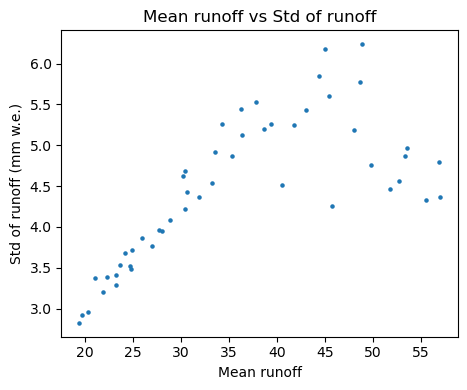

In [17]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),

plt.tight_layout()
plt.show()

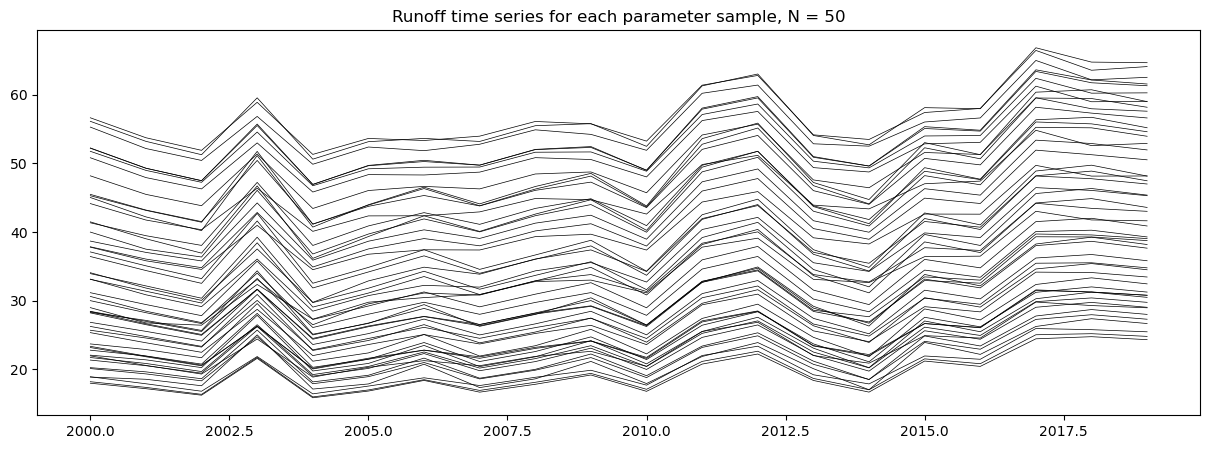

In [22]:
# compile csvs to plot timeseries and plot to view the runoff time series for each of the 50 samples, to see how they are looking and check that they make sense before we calculate the sensitivity indices
import pandas as pd

plt.figure(figsize=(15,5))

for i in range(N):
    df = pd.read_csv(cfg.PATHS['working_dir'] + '/' + str(i) + '_runoff_output.csv')
    plt.plot(df['years'], df['runoff'], label='sim', color='k', linewidth=0.5)
    plt.title('Runoff time series for each parameter sample, N = %d' % N)

In [19]:
# Define interactive visualisation function to calculate and visualise sensitivity indices
# for the chosen output metric and different choices of the PAWN tuning parameters (n,Nboot,aggr)

def runoff_pawn_function(metric='Mean Runoff', n = 5, aggr = 'median', Nboot = 500):
    # Extract output metric:
    if metric == 'Mean Runoff':
        i = 0
    elif metric == 'Std of Runoff':
        i = 1   
    Y = YY[:, i]; 

    X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
    
    # Apply PAWN
    # Tuning parameters:
    # n = number of conditioning intervals
    # aggr = statistic to aggregate KS values
    # Nboot = number of bootstrapping resamples used to derive confidence bounds of sensitivity indices   

    # Compute sensitivity indices for Nboot bootstrap resamples
    KS_median, KS_mean, KS_max = PAWN.pawn_indices(X, Y, n, Nboot=Nboot)
    # KS_median and KS_mean and KS_max have shape (Nboot, M)
        
    # Compute mean and confidence intervals of the sensitivity indices across the bootstrap resamples:
    KS_median_m, KS_median_lb, KS_median_ub = aggregate_boot(KS_median) # shape (M,)
    KS_mean_m, KS_mean_lb, KS_mean_ub = aggregate_boot(KS_mean) # shape (M,)
    KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_max) # shape (M,)

    # Plot sensitivity indices:
    plt.figure()
    plt.title("Output Metric for the Runoff = %s" % metric)
    if aggr == 'median':
        pf.boxplot1(KS_median_m, S_lb=KS_median_lb, S_ub=KS_median_ub, X_Labels=X_labels, Y_Label='sensitivity (median KS)')
    if aggr == 'mean':
        pf.boxplot1(KS_mean_m, S_lb=KS_mean_lb, S_ub=KS_mean_ub, X_Labels=X_labels, Y_Label='sensitivity (mean KS)')
    if aggr == 'max':
        pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, X_Labels=X_labels, Y_Label='sensitivity (max KS)')
    plt.show()

interact(runoff_pawn_function, metric = ['Mean Runoff','Std of Runoff'], n = (2, 20, 1), aggr = ['median', 'mean','max'], Nboot = (0, 500, 10));


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…